# Define

Use hota hai jab hume data ko categories (classes) mein divide karna ho.

Naive Bayes assume karta hai ki ye features ek dusre ko affect nahi karte.

Naive Bayes ek classification algorithm hai jo Bayes Theorem par based hota hai.

# Mathematical Behind Naives

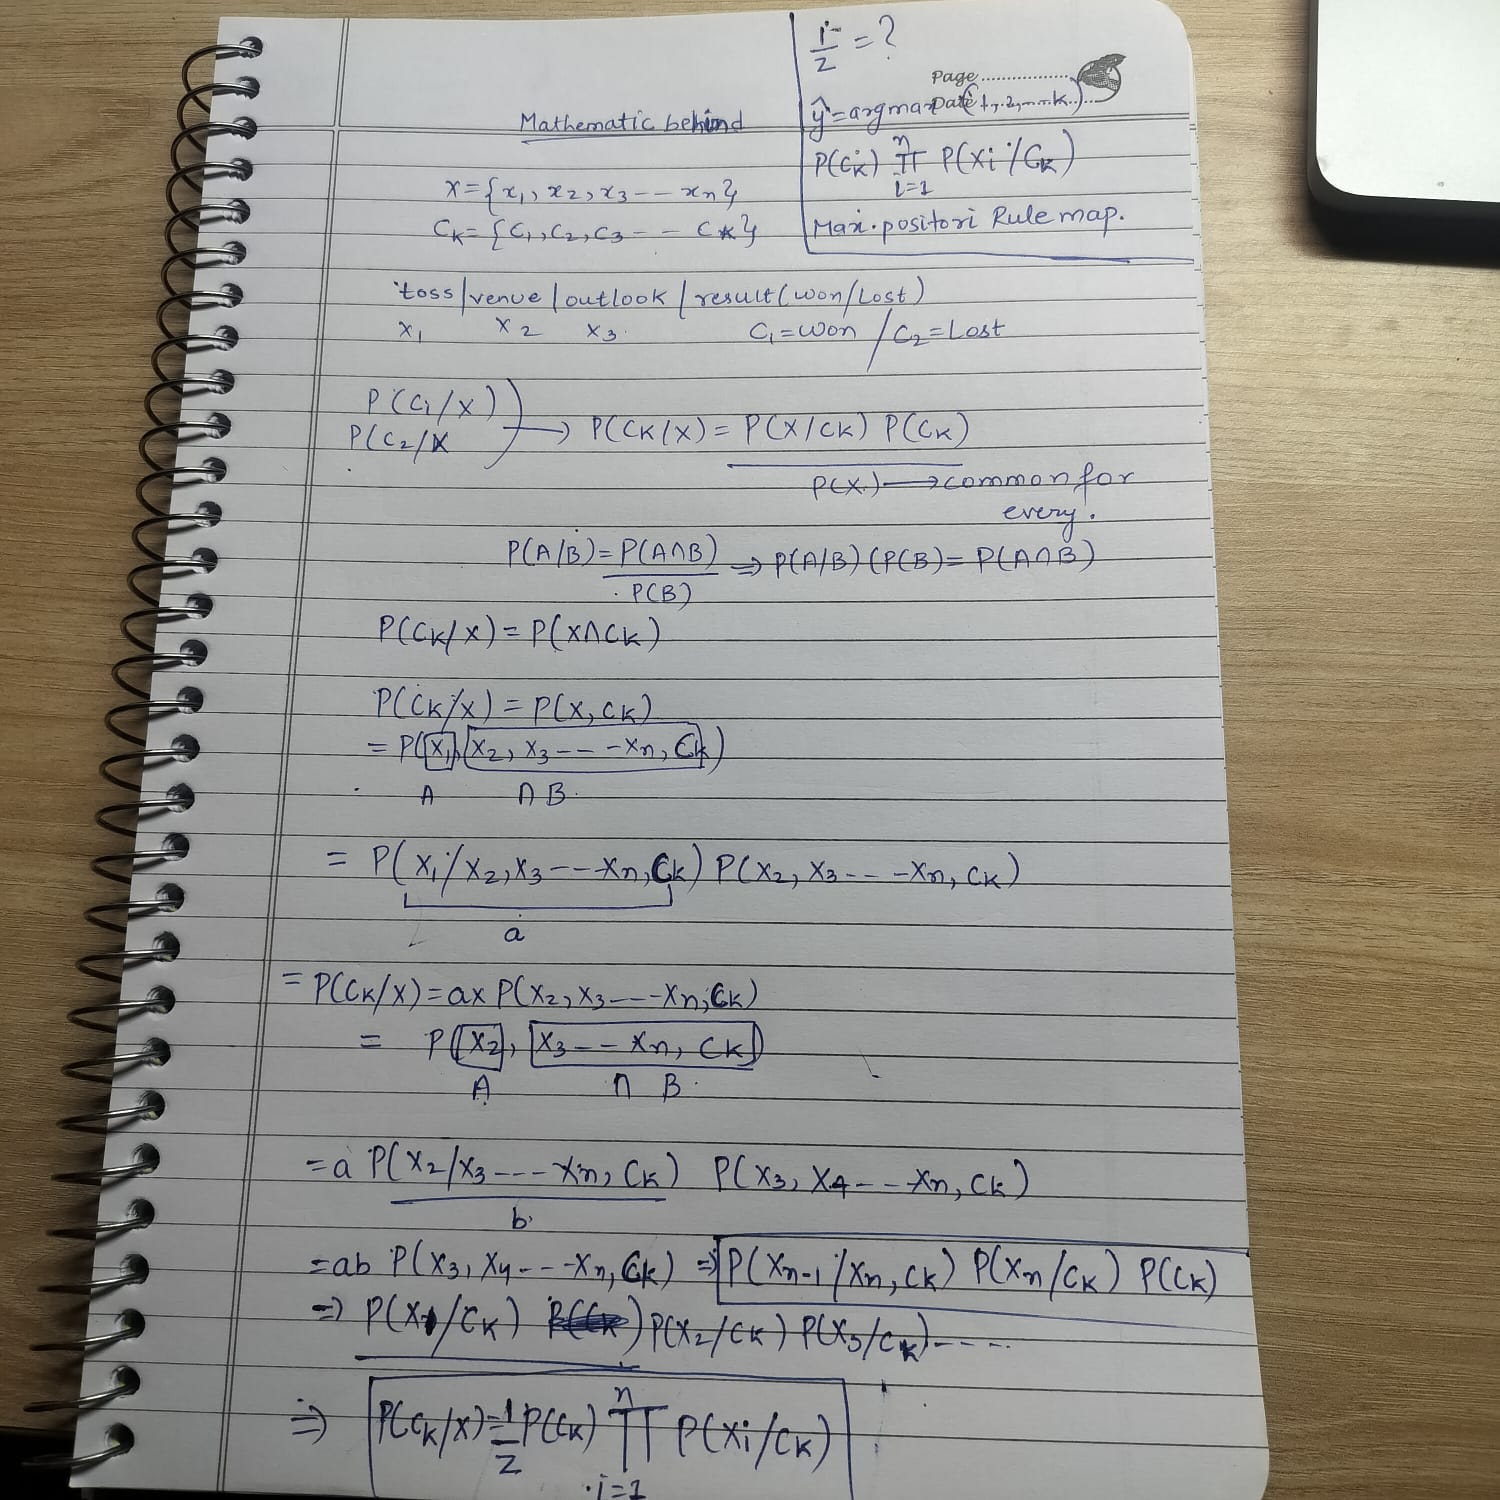

# Types of Naive Bayes

1️⃣ Gaussian Naive Bayes

Continuous data ke liye

Example: height, weight

2️⃣ Multinomial Naive Bayes

Text classification ke liye

Spam detection, NLP

3️⃣ Bernoulli Naive Bayes

Binary features (0 / 1)

In [54]:
from sklearn.naive_bayes import GaussianNB
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

# Separate features (X) and target (y)
X = data.drop('play', axis=1)
y = data['play']

# Encode categorical features
le = LabelEncoder()
for column in X.columns:
    X[column] = le.fit_transform(X[column])

# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

model = GaussianNB()

model.fit(X_train, y_train)

y_pred = model.predict(X_test)

fit() → model train karta hai

predict() → prediction karta hai

# Code

In [1]:
import numpy as np
import pandas as pd


In [16]:
data = pd.read_csv('play_tennis.csv')
data.head()
data.drop(columns=['day'],inplace = True)


In [17]:
data

,outlook,temp,humidity,wind,play
0,Sunny,Hot,High,Weak,No
1,Sunny,Hot,High,Strong,No
2,Overcast,Hot,High,Weak,Yes
3,Rain,Mild,High,Weak,Yes
4,Rain,Cool,Normal,Weak,Yes
5,Rain,Cool,Normal,Strong,No
6,Overcast,Cool,Normal,Strong,Yes
7,Sunny,Mild,High,Weak,No
8,Sunny,Cool,Normal,Weak,Yes
9,Rain,Mild,Normal,Weak,Yes


In [ ]:
# problem 1

# Outlook = Sunny, temp = hot,humidity = high,wind = weak
# Play or notPlay?


In [ ]:
# Solution

# P(Yes/Sunny,Hot,High,Weak) = P(Sunny/Yes)*P(Hot/Yes)*P(High/Yes)*P(Weak/Yes) * P(Yes)
# P(No/Sunny,Hot,High,Weak) = P(Sunny/No)*P(Hot/No)*P(High/No)*P(Weak/No) * P(No)
# Compare and decide a maximum a posteririo rule

In [ ]:
# Training

# Lookup Table (Dictionary)

# Testing

In [ ]:
# P(Yes)

# P(No)

In [18]:
data['play'].value_counts()

,count
play,
Yes,9
No,5


In [30]:
p_yes = 9/14
p_no = 5/14

In [31]:
print(p_yes)



0.6428571428571429


In [33]:
print(p_no)

0.35714285714285715


In [34]:
# Outlook

pd.crosstab(data['outlook'],data['play'])

play,No,Yes
outlook,,
Overcast,0,4
Rain,2,3
Sunny,3,2


In [35]:
Pon = 0
Prn = 2/5
Psn = 3/5

Poy = 4/9
Pry = 3/9
Psy = 2/9

In [36]:
# temp

pd.crosstab(data['temp'],data['play'])

play,No,Yes
temp,,
Cool,1,3
Hot,2,2
Mild,2,4


In [37]:
PCoolNo = 1/5
PHotNo = 2/5
PMildNo = 2/5

PCoolYes = 3/9
PHotYes = 2/9
PMildYes = 4/9

In [39]:
# Humidity

pd.crosstab(data['humidity'],data['play'])

play,No,Yes
humidity,,
High,4,3
Normal,1,6


In [40]:
PHighNo = 4/5
PNormalNo = 1/5

PHighYes = 3/9
PNormalYes = 6/9

In [42]:
# wind

pd.crosstab(data['wind'],data['play'])

play,No,Yes
wind,,
Strong,3,3
Weak,2,6


In [44]:
PStrongNo = 3/5
PWeakNo = 2/5

PStrongYes = 3/9
PWeakyes = 6/9

In [48]:
Pyes = p_yes * Psy * PHotYes * PHighYes * PWeakyes
Pno = p_no * Psn * PHotNo * PHighNo * PWeakNo



In [50]:
Pyes

0.007054673721340388

In [51]:
Pno

0.02742857142857143

In [52]:
Pyes = p_yes * Psy * PHotYes * PHighYes * PWeakyes
Pno = p_no * Psn * PHotNo * PHighNo * PWeakNo

print(f"P(Yes) = {Pyes}")
print(f"P(No) = {Pno}")

if Pyes > Pno:
    print("Decision: Play (Yes)")
else:
    print("Decision: Not Play (No)")

P(Yes) = 0.007054673721340388
P(No) = 0.02742857142857143
Decision: Not Play (No)


# Key Idea (Hinglish)

Categorical data → Multinomial / Bernoulli Naive Bayes

Numerical data → Gaussian Naive Bayes

# If in naives bayes me numercial data ho to hum Gaussian Naive Bayes use karte hai

# Main idea: har class ke liye feature values ko normal (Gaussian) distribution se model kiya jata hai.



# Numerical data → Gaussian Naive Bayes

Small Numerical Example

Suppose training data:

Height	Class
170	Male
180	Male
175	Male
160	Female
155	Female
165	Female
Step 1: Mean

Male mean
(170 + 180 + 175) / 3 = 175

Female mean
(160 + 155 + 165) / 3 = 160

Step 2: Variance

Calculate variance for each class (spread of values).

Male variance ≈ 16.67
Female variance ≈ 16.67

Step 3: Prediction

Suppose new person height = 172

Compute:

𝑃
(
172
∣
𝑀
𝑎
𝑙
𝑒
)
P(172∣Male)

𝑃
(
172
∣
𝐹
𝑒
𝑚
𝑎
𝑙
𝑒
)
P(172∣Female)

Using Gaussian formula above.

Whichever probability is higher, that class is predicted.

# steps to calculate

Calculate mean & variance for each feature per class

Use Gaussian formula

Multiply probabilities with prior

Choose highest probability class

# Formula

f(x) = P(x|C)=\frac{1}{\sqrt{2\pi\sigma^2}},e^{-\frac{(x-\mu)^2}{2\sigma^2}}

Where

x = feature value

μ (mu) = mean

σ² (sigma²) = variance

e ≈ 2.718